# IMPORT LIBRARIES

In [1]:
import cv2
import numpy as np
import pandas as pd
import face_recognition
import pickle
import os
from datetime import datetime

# LOAD DATASET

In [2]:
with open('faces_data.pkl', 'rb') as f:
    faces_data = pickle.load(f)

print("Dataset Loaded:", len(faces_data))

Dataset Loaded: 150


# CREATE FACE ENCODINGS

In [3]:
# ==============================
# FINAL FIXED ENCODING CELL
# ==============================

encodings = []
labels = []

import numpy as np
import cv2
import face_recognition

print("Type:", type(faces_data))

# ------------------------------
# HANDLE NUMPY DATASET
# ------------------------------
if isinstance(faces_data, np.ndarray):

    print("✅ Numpy dataset detected")
    print("Shape:", faces_data.shape)

    for i in range(len(faces_data)):
        img = faces_data[i]

        try:
            # Try reshape (common sizes)
            if len(img.shape) == 1:
                img = img.reshape(50, 50, 3)   # try 50x50 first
        except:
            pass

        img = img.astype('uint8')

        try:
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except:
            continue

        face_enc = face_recognition.face_encodings(rgb)

        if len(face_enc) > 0:
            encodings.append(face_enc[0])
            labels.append(f"Person_{i}")   # auto label

# ------------------------------
# HANDLE DICTIONARY (backup)
# ------------------------------
elif isinstance(faces_data, dict):

    print("✅ Dictionary dataset detected")

    for label, images in faces_data.items():
        for img in images:
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            face_enc = face_recognition.face_encodings(rgb)

            if len(face_enc) > 0:
                encodings.append(face_enc[0])
                labels.append(label)

else:
    print("❌ Unsupported dataset type")

print("🎯 Total Encodings Created:", len(encodings))

Type: <class 'numpy.ndarray'>
✅ Numpy dataset detected
Shape: (150, 7500)
🎯 Total Encodings Created: 132


# SAVE MODEL

In [4]:
data = {"encodings": encodings, "labels": labels}

with open("face_model.pkl", "wb") as f:
    pickle.dump(data, f)

print("Model Saved")

Model Saved


# TEST REAL-TIME RECOGNITION + SAVE ATTENDANCE

In [5]:
# ==============================
# TEST + ATTENDANCE SAVE (FINAL FIX)
# ==============================

import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from IPython.display import display, clear_output
import time

cap = cv2.VideoCapture(0)

attendance = []   # ✅ IMPORTANT (define here)

start_time = time.time()
duration = 5   # run for 5 sec

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    faces = face_recognition.face_locations(rgb)
    face_encs = face_recognition.face_encodings(rgb, faces)

    for face_enc, face_loc in zip(face_encs, faces):
        matches = face_recognition.compare_faces(encodings, face_enc)
        name = "Unknown"

        face_dist = face_recognition.face_distance(encodings, face_enc)

        if len(face_dist) > 0:
            best_match = np.argmin(face_dist)
            if matches[best_match]:
                name = labels[best_match]

                now = datetime.now()
                attendance.append([
                    name,
                    now.strftime("%Y-%m-%d"),
                    now.strftime("%H:%M:%S")
                ])

        top, right, bottom, left = face_loc
        cv2.rectangle(frame, (left, top), (right, bottom), (0,255,0), 2)
        cv2.putText(frame, name, (left, top-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    clear_output(wait=True)
    display(rgb)

    if time.time() - start_time > duration:
        break

cap.release()

# ==============================
# SAVE ATTENDANCE
# ==============================

if len(attendance) == 0:
    print("⚠ No attendance captured")
else:
    df = pd.DataFrame(attendance, columns=["Name","Date","Time"])
    df.drop_duplicates(subset=["Name","Date"], inplace=True)

    file = f"attendance_{datetime.now().strftime('%Y-%m-%d')}.csv"
    df.to_csv(file, index=False)

    print("✅ Attendance Saved:", file)
    display(df)

array([[[ 16, 107,  63],
        [ 13, 104,  60],
        [  8, 105,  59],
        ...,
        [ 65, 148, 107],
        [ 75, 161, 114],
        [ 82, 168, 121]],

       [[ 15, 107,  63],
        [ 13, 105,  61],
        [  8, 105,  59],
        ...,
        [ 71, 154, 113],
        [ 69, 157, 112],
        [ 73, 161, 116]],

       [[ 16, 108,  64],
        [ 13, 105,  61],
        [  9, 104,  59],
        ...,
        [ 71, 156, 112],
        [ 69, 157, 112],
        [ 69, 157, 112]],

       ...,

       [[ 20,  75,  35],
        [ 20,  75,  35],
        [ 26,  81,  41],
        ...,
        [  9,  23,  12],
        [ 15,  27,  14],
        [ 20,  32,  19]],

       [[ 17,  74,  33],
        [ 15,  72,  31],
        [ 22,  77,  39],
        ...,
        [  5,  22,  10],
        [ 10,  24,  13],
        [ 17,  31,  20]],

       [[  8,  70,  29],
        [  9,  71,  30],
        [ 15,  70,  30],
        ...,
        [  1,  22,  13],
        [  5,  22,  10],
        [  7,  24,  12]]

✅ Attendance Saved: attendance_2026-08-08.csv


,Name,Date,Time
0,Person_70,2026-08-08,12:13:35


# VISUALIZATION

Using file: attendance_log.csv

Preview:
         Name        Date      Time
0  Person_133  2026-07-29  11:32:51
1      bhakti  2026-07-29  11:32:53
2  Person_101  2026-07-29  14:33:15
3  Person_101  2026-07-29  14:33:21


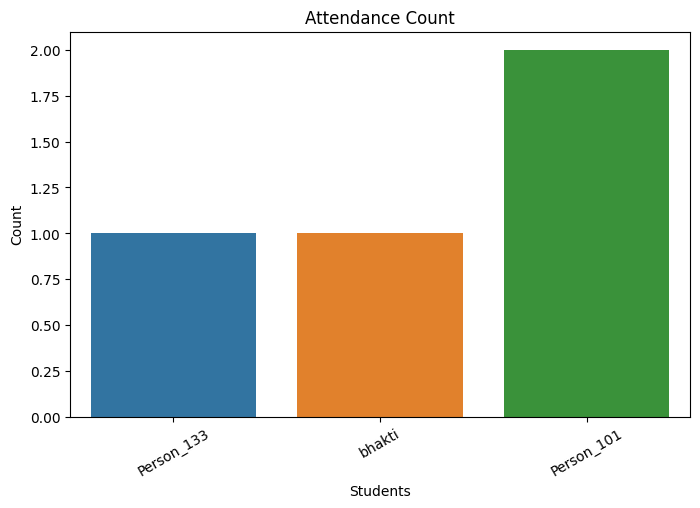

In [6]:
# ==============================
# FIXED ATTENDANCE VISUALIZATION
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------
# FIND ATTENDANCE FILE
# ------------------------------
files = [f for f in os.listdir() if f.startswith("attendance") and f.endswith(".csv")]

if len(files) == 0:
    print("❌ No attendance file found. Run attendance first.")
else:
    latest_file = sorted(files)[-1]   # latest file
    print("Using file:", latest_file)

    df = pd.read_csv(latest_file)

    print("\nPreview:")
    print(df.head())

    # ------------------------------
    # PLOT
    # ------------------------------
    plt.figure(figsize=(8,5))
    sns.countplot(x="Name", data=df)
    plt.title("Attendance Count")
    plt.xticks(rotation=30)
    plt.xlabel("Students")
    plt.ylabel("Count")
    plt.show()

# STREAMLIT APP

In [11]:
# ============================================================
# SMART FACE BASED ATTENDANCE SYSTEM
# FULL FIXED VERSION
# OLD FEATURES + FACE REGISTRATION + FACE LOGIN
# + FACE VERIFIED ATTENDANCE
# + AUTOMATIC CSV MIGRATION
# ============================================================

import sys
import os
import subprocess
import time
import webbrowser

# ============================================================
# STOP OLD STREAMLIT
# ============================================================

os.system("taskkill /f /im streamlit.exe >nul 2>&1")

# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

packages = [
    "streamlit",
    "pandas",
    "plotly",
    "numpy",
    "pillow",
    "opencv-python",
    "face_recognition"
]

for package in packages:

    try:

        if package == "opencv-python":
            import cv2

        elif package == "face_recognition":
            import face_recognition

        else:
            __import__(package.replace("-", "_"))

    except:

        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                package,
                "-q"
            ],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )


# ============================================================
# APP FILE
# ============================================================

APP_FILE = "app.py"


# ============================================================
# STREAMLIT APPLICATION
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import hashlib
import os
import pickle
import numpy as np
from datetime import datetime

# ============================================================
# FACE RECOGNITION
# ============================================================

try:

    import face_recognition

    FACE_AVAILABLE = True

except Exception:

    FACE_AVAILABLE = False


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Face Attendance System",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# FILES
# ============================================================

USER_FILE = "users.csv"
ATT_FILE = "attendance.csv"
TIME_FILE = "timetable.csv"
TEACH_FILE = "teachers.csv"
FACE_FILE = "faces.pkl"


# ============================================================
# CSS
# ============================================================

st.markdown("""
<style>

.stButton>button {

    width:100%;
    border-radius:10px;
    font-weight:600;

}

.metric-card {

    background:#161b22;
    padding:20px;
    border-radius:15px;
    border:1px solid #30363d;

}

</style>
""", unsafe_allow_html=True)


# ============================================================
# REQUIRED COLUMNS
# ============================================================

ATT_COLUMNS = [
    "Name",
    "Date",
    "Time",
    "Subject",
    "Section",
    "Verification"
]

USER_COLUMNS = [
    "username",
    "password",
    "role",
    "section"
]

TEACH_COLUMNS = [
    "subject",
    "faculty",
    "section"
]

TIME_COLUMNS = [
    "Day",
    "Section",
    "09-10",
    "10-11",
    "11-12",
    "12-01",
    "01-02",
    "02-03",
    "03-04",
    "04-05"
]


# ============================================================
# SAFE CSV LOADER
# ============================================================

def safe_read_csv(
    file,
    columns
):

    if not os.path.exists(file):

        return pd.DataFrame(
            columns=columns
        )

    try:

        df = pd.read_csv(file)

    except Exception:

        return pd.DataFrame(
            columns=columns
        )

    # --------------------------------------------------------
    # ADD MISSING COLUMNS
    # --------------------------------------------------------

    for col in columns:

        if col not in df.columns:

            if col == "Verification":

                df[col] = "LEGACY"

            else:

                df[col] = ""

    # --------------------------------------------------------
    # KEEP REQUIRED COLUMNS FIRST
    # --------------------------------------------------------

    extra = [
        c for c in df.columns
        if c not in columns
    ]

    df = df[
        columns + extra
    ]

    return df


# ============================================================
# INITIALIZE USER FILE
# ============================================================

if not os.path.exists(USER_FILE):

    pd.DataFrame(
        columns=USER_COLUMNS
    ).to_csv(
        USER_FILE,
        index=False
    )


# ============================================================
# INITIALIZE ATTENDANCE FILE
# ============================================================

if not os.path.exists(ATT_FILE):

    pd.DataFrame(
        columns=ATT_COLUMNS
    ).to_csv(
        ATT_FILE,
        index=False
    )

else:

    # AUTOMATIC MIGRATION
    # This fixes the exact error from screenshot

    attendance_migration = safe_read_csv(
        ATT_FILE,
        ATT_COLUMNS
    )

    attendance_migration.to_csv(
        ATT_FILE,
        index=False
    )


# ============================================================
# INITIALIZE TEACHER FILE
# ============================================================

if not os.path.exists(TEACH_FILE):

    pd.DataFrame(
        columns=TEACH_COLUMNS
    ).to_csv(
        TEACH_FILE,
        index=False
    )


# ============================================================
# TIMETABLE
# ============================================================

if not os.path.exists(TIME_FILE):

    timetable = pd.DataFrame([

        [
            "Monday","A",
            "AI","ML","DBMS","BREAK",
            "OS","CN","SE","AI"
        ],

        [
            "Monday","B",
            "ML","AI","OS","BREAK",
            "DBMS","SE","CN","ML"
        ],

        [
            "Monday","C",
            "DBMS","CN","AI","BREAK",
            "ML","OS","SE","CN"
        ],

        [
            "Tuesday","A",
            "ML","AI","CN","BREAK",
            "DBMS","OS","SE","DBMS"
        ],

        [
            "Tuesday","B",
            "AI","ML","DBMS","BREAK",
            "OS","CN","SE","OS"
        ],

        [
            "Tuesday","C",
            "CN","DBMS","ML","BREAK",
            "AI","SE","OS","ML"
        ],

        [
            "Wednesday","A",
            "DBMS","CN","AI","BREAK",
            "ML","OS","SE","CN"
        ],

        [
            "Wednesday","B",
            "OS","DBMS","ML","BREAK",
            "AI","SE","CN","AI"
        ],

        [
            "Wednesday","C",
            "ML","AI","CN","BREAK",
            "DBMS","OS","SE","DBMS"
        ],

        [
            "Thursday","A",
            "CN","OS","ML","BREAK",
            "AI","DBMS","SE","ML"
        ],

        [
            "Thursday","B",
            "AI","CN","OS","BREAK",
            "ML","DBMS","SE","DBMS"
        ],

        [
            "Thursday","C",
            "DBMS","ML","AI","BREAK",
            "OS","CN","SE","AI"
        ],

        [
            "Friday","A",
            "SE","ML","AI","BREAK",
            "CN","OS","DBMS","AI"
        ],

        [
            "Friday","B",
            "DBMS","SE","CN","BREAK",
            "AI","ML","OS","ML"
        ],

        [
            "Friday","C",
            "AI","CN","OS","BREAK",
            "ML","DBMS","SE","CN"
        ],

        [
            "Saturday","A",
            "AI","DBMS","ML","BREAK",
            "OS","CN","SE","FREE"
        ],

        [
            "Saturday","B",
            "ML","AI","OS","BREAK",
            "DBMS","SE","CN","FREE"
        ],

        [
            "Saturday","C",
            "CN","ML","DBMS","BREAK",
            "AI","OS","SE","FREE"
        ]

    ], columns=TIME_COLUMNS)

    timetable.to_csv(
        TIME_FILE,
        index=False
    )


# ============================================================
# FACE DATABASE
# ============================================================

if not os.path.exists(FACE_FILE):

    with open(
        FACE_FILE,
        "wb"
    ) as f:

        pickle.dump(
            {},
            f
        )


# ============================================================
# FACE DATABASE FUNCTIONS
# ============================================================

def load_faces():

    try:

        with open(
            FACE_FILE,
            "rb"
        ) as f:

            data = pickle.load(f)

        if isinstance(data, dict):

            return data

        return {}

    except Exception:

        return {}


def save_faces(data):

    with open(
        FACE_FILE,
        "wb"
    ) as f:

        pickle.dump(
            data,
            f
        )


# ============================================================
# PASSWORD HASH
# ============================================================

def hash_pass(password):

    return hashlib.sha256(
        password.encode()
    ).hexdigest()


# ============================================================
# REGISTER USER
# ============================================================

def register_user(
    username,
    password,
    role,
    section,
    face_image=None
):

    username = username.strip()

    password = password.strip()

    users = safe_read_csv(
        USER_FILE,
        USER_COLUMNS
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    if username == "":

        return False, "Username is required."

    if password == "":

        return False, "Password is required."

    if username in users.username.astype(str).values:

        return False, "Username already exists."


    # --------------------------------------------------------
    # STUDENT FACE REGISTRATION
    # --------------------------------------------------------

    if role == "student":

        if not FACE_AVAILABLE:

            return False, (
                "face_recognition is not available."
            )

        if face_image is None:

            return False, (
                "Student face is required."
            )

        try:

            image = face_recognition.load_image_file(
                face_image
            )

            locations = face_recognition.face_locations(
                image
            )

            if len(locations) == 0:

                return False, (
                    "No face detected. "
                    "Please capture your face clearly."
                )

            if len(locations) > 1:

                return False, (
                    "Multiple faces detected. "
                    "Only one face should be visible."
                )

            encodings = face_recognition.face_encodings(
                image,
                locations
            )

            if len(encodings) == 0:

                return False, (
                    "Unable to generate face encoding."
                )

            encoding = encodings[0]

            faces = load_faces()

            # Prevent duplicate username
            faces[username] = encoding

            save_faces(faces)

        except Exception as e:

            return False, (
                "Face registration failed."
            )


    # --------------------------------------------------------
    # SAVE USER
    # --------------------------------------------------------

    users.loc[
        len(users)
    ] = [
        username,
        hash_pass(password),
        role,
        section
    ]

    users.to_csv(
        USER_FILE,
        index=False
    )

    return True, (
        "Registration successful."
    )


# ============================================================
# VERIFY FACE
# ============================================================

def verify_face(
    username,
    image_file
):

    if not FACE_AVAILABLE:

        return False, (
            "Face recognition library unavailable."
        )

    if image_file is None:

        return False, (
            "Face image required."
        )

    faces = load_faces()

    if username not in faces:

        return False, (
            "No registered face found "
            "for this student."
        )

    try:

        image = face_recognition.load_image_file(
            image_file
        )

        locations = face_recognition.face_locations(
            image
        )

        if len(locations) == 0:

            return False, (
                "No face detected."
            )

        if len(locations) > 1:

            return False, (
                "Multiple faces detected. "
                "Only one face should be visible."
            )

        encodings = face_recognition.face_encodings(
            image,
            locations
        )

        if len(encodings) == 0:

            return False, (
                "Face encoding failed."
            )

        current_encoding = encodings[0]

        registered_encoding = np.asarray(
            faces[username]
        )

        distance = face_recognition.face_distance(
            [registered_encoding],
            current_encoding
        )[0]

        # Strict threshold
        THRESHOLD = 0.50

        if distance <= THRESHOLD:

            return True, (
                f"Face verified successfully "
                f"(distance: {distance:.3f})"
            )

        return False, (
            f"Face mismatch "
            f"(distance: {distance:.3f})"
        )

    except Exception:

        return False, (
            "Face verification failed."
        )


# ============================================================
# LOGIN
# ============================================================

def login_user(
    username,
    password,
    role,
    section,
    face_image=None
):

    users = safe_read_csv(
        USER_FILE,
        USER_COLUMNS
    )

    username = username.strip()

    password = password.strip()

    if role == "faculty":
        matched = users[
            (users.username.astype(str) == username) &
            (users.password.astype(str) == hash_pass(password)) &
            (users.role.astype(str) == role)
        ]
    else:
        matched = users[
            (users.username.astype(str) == username) &
            (users.password.astype(str) == hash_pass(password)) &
            (users.role.astype(str) == role) &
            (users.section.astype(str) == section)
        ]

    if len(matched) == 0:

        return False, (
            "Invalid username, password, role "
            "or section."
        )

    # Student requires face
    if role == "student":

        verified, message = verify_face(
            username,
            face_image
        )

        if not verified:

            return False, message

    return True, "Login successful."


# ============================================================
# CURRENT SUBJECT
# ============================================================

def current_subject(section):

    df = safe_read_csv(
        TIME_FILE,
        TIME_COLUMNS
    )

    day = datetime.now().strftime(
        "%A"
    )

    hour = int(
        datetime.now().strftime("%H")
    )

    mapping = {

        9: "09-10",
        10: "10-11",
        11: "11-12",
        12: "12-01",
        13: "01-02",
        14: "02-03",
        15: "03-04",
        16: "04-05"

    }

    if hour not in mapping:

        return "FREE"

    row = df[
        (df.Day.astype(str) == day) &
        (df.Section.astype(str) == section)
    ]

    if row.empty:

        return "FREE"

    return str(
        row.iloc[0][
            mapping[hour]
        ]
    )


# ============================================================
# NEXT CLASS
# ============================================================

def get_next_class(section):

    df = safe_read_csv(
        TIME_FILE,
        TIME_COLUMNS
    )

    day = datetime.now().strftime(
        "%A"
    )

    hour = int(
        datetime.now().strftime("%H")
    )

    mapping = {

        9: "09-10",
        10: "10-11",
        11: "11-12",
        12: "12-01",
        13: "01-02",
        14: "02-03",
        15: "03-04",
        16: "04-05"

    }

    future = [
        h for h in mapping
        if h > hour
    ]

    row = df[
        (df.Day.astype(str) == day) &
        (df.Section.astype(str) == section)
    ]

    if row.empty:

        return "No class"

    for h in future:

        subject = str(
            row.iloc[0][
                mapping[h]
            ]
        )

        if subject not in [
            "FREE",
            "BREAK"
        ]:

            return (
                f"{mapping[h]} → {subject}"
            )

    return "No upcoming class"


# ============================================================
# MARK FACE ATTENDANCE
# ============================================================

def mark_face_attendance(
    username,
    section,
    face_image
):

    # --------------------------------------------------------
    # CURRENT SUBJECT
    # --------------------------------------------------------

    subject = current_subject(
        section
    )

    if subject in [
        "FREE",
        "BREAK",
        "nan"
    ]:

        return False, (
            "No class is running right now."
        )


    # --------------------------------------------------------
    # FACE VERIFICATION FIRST
    # --------------------------------------------------------

    verified, message = verify_face(
        username,
        face_image
    )

    if not verified:

        return False, message


    # --------------------------------------------------------
    # READ ATTENDANCE SAFELY
    # --------------------------------------------------------

    df = safe_read_csv(
        ATT_FILE,
        ATT_COLUMNS
    )


    # --------------------------------------------------------
    # DATE
    # --------------------------------------------------------

    today = datetime.now().strftime(
        "%Y-%m-%d"
    )


    # --------------------------------------------------------
    # DUPLICATE CHECK
    # --------------------------------------------------------

    already = df[
        (df.Name.astype(str) == username) &
        (df.Date.astype(str) == today) &
        (df.Subject.astype(str) == subject) &
        (df.Section.astype(str) == section)
    ]

    if len(already) > 0:

        return False, (
            "Attendance already marked "
            "for this subject today."
        )


    # --------------------------------------------------------
    # IMPORTANT FIX
    # ALWAYS CREATE ROW WITH EXACT COLUMNS
    # --------------------------------------------------------

    new_record = {

        "Name": username,

        "Date": today,

        "Time": datetime.now().strftime(
            "%H:%M:%S"
        ),

        "Subject": subject,

        "Section": section,

        "Verification": "FACE VERIFIED"

    }

    df = pd.concat(
        [
            df,
            pd.DataFrame(
                [new_record],
                columns=ATT_COLUMNS
            )
        ],
        ignore_index=True
    )


    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    df.to_csv(
        ATT_FILE,
        index=False
    )

    return True, (
        "Attendance marked successfully."
    )


# ============================================================
# SESSION
# ============================================================

if "login" not in st.session_state:

    st.session_state.login = False

    st.session_state.user = ""

    st.session_state.role = ""

    st.session_state.section = ""


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title(
    "🔐 Authentication"
)

mode = st.sidebar.radio(
    "Mode",
    ["Login", "Register"],
    key="auth_mode"
)

role_box = st.sidebar.selectbox(
    "Role",
    ["admin", "faculty", "student"],
    key="auth_role"
)

section_box = st.sidebar.selectbox(
    "Section",
    ["A", "B", "C"],
    key="auth_section"
)

username = st.sidebar.text_input(
    "Username",
    key="auth_username"
)

password = st.sidebar.text_input(
    "Password",
    type="password",
    key="auth_password"
)


# ============================================================
# REGISTER
# ============================================================

if mode == "Register":

    st.sidebar.subheader(
        "📝 Registration"
    )

    register_face = None

    if role_box == "student":

        st.sidebar.info(
            "Student registration requires face."
        )

        register_face = st.sidebar.camera_input(
            "📸 Capture Registration Face",
            key="register_camera"
        )

    if st.sidebar.button(
        "📝 Register",
        key="register_button"
    ):

        success, message = register_user(
            username,
            password,
            role_box,
            section_box,
            register_face
        )

        if success:

            st.sidebar.success(
                message
            )

        else:

            st.sidebar.error(
                message
            )


# ============================================================
# LOGIN
# ============================================================

if mode == "Login":

    login_face = None

    if role_box == "student":

        st.sidebar.info(
            "Student login requires "
            "password + registered face."
        )

        login_face = st.sidebar.camera_input(
            "📸 Capture Login Face",
            key="login_camera"
        )

    if st.sidebar.button(
        "🔑 Login",
        key="login_button"
    ):

        success, message = login_user(
            username,
            password,
            role_box,
            section_box,
            login_face
        )

        if success:

            st.session_state.login = True

            st.session_state.user = username

            st.session_state.role = role_box

            st.session_state.section = section_box

            st.rerun()

        else:

            st.sidebar.error(
                message
            )


# ============================================================
# LOGOUT
# ============================================================

if st.sidebar.button(
    "🚪 Logout",
    key="logout_button"
):

    st.session_state.login = False

    st.session_state.user = ""

    st.session_state.role = ""

    st.session_state.section = ""

    st.rerun()


# ============================================================
# MAIN
# ============================================================

if st.session_state.login:

    role = st.session_state.role

    user = st.session_state.user

    section = st.session_state.section


    # ========================================================
    # HEADER
    # ========================================================

    st.title(
        "🎓 SMART FACE ATTENDANCE SYSTEM"
    )

    st.caption(
        f"User: {user} | "
        f"Role: {role.upper()} | "
        f"Section: {section}"
    )


    # ========================================================
    # LOAD DATA
    # ========================================================

    df_att = safe_read_csv(
        ATT_FILE,
        ATT_COLUMNS
    )

    df_time = safe_read_csv(
        TIME_FILE,
        TIME_COLUMNS
    )


    # ========================================================
    # CURRENT CLASS
    # ========================================================

    current = current_subject(
        section
    )

    next_class = get_next_class(
        section
    )


    # ========================================================
    # TOP METRICS
    # ========================================================

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "🟢 Current Class",
            current
        )

    with col2:

        st.metric(
            "⏭️ Next Class",
            next_class
        )

    with col3:

        st.metric(
            "📋 Total Attendance",
            len(df_att)
        )


    if current in [
        "FREE",
        "BREAK"
    ]:

        st.warning(
            "🟡 No class running right now."
        )

    else:

        st.success(
            f"🟢 Current Class: {current}"
        )


    # ========================================================
    # ADMIN
    # ========================================================

    if role == "admin":

        menu = st.sidebar.radio(

            "Admin Menu",

            [
                "Dashboard",
                "Users",
                "Delete User",
                "Assign Teacher",
                "View Students",
                "Timetable",
                "Edit Timetable",
                "Section Graph",
                "Monthly Graph",
                "Face Database"
            ],

            key="admin_menu"

        )


        # ====================================================
        # DASHBOARD
        # ====================================================

        if menu == "Dashboard":

            users_df = safe_read_csv(
                USER_FILE,
                USER_COLUMNS
            )

            faces = load_faces()

            c1,c2,c3,c4 = st.columns(4)

            with c1:

                st.metric(
                    "👥 Total Users",
                    len(users_df)
                )

            with c2:

                st.metric(
                    "🎓 Students",
                    len(
                        users_df[
                            users_df.role == "student"
                        ]
                    )
                )

            with c3:

                st.metric(
                    "📋 Attendance",
                    len(df_att)
                )

            with c4:

                st.metric(
                    "🔐 Registered Faces",
                    len(faces)
                )


            st.subheader(
                "📊 Complete Attendance Report"
            )

            st.dataframe(
                df_att,
                use_container_width=True
            )


            csv = df_att.to_csv(
                index=False
            ).encode(
                "utf-8"
            )


            st.download_button(

                "📥 Download Full Report",

                csv,

                "attendance_full.csv",

                "text/csv",

                key="admin_download"

            )


        # ====================================================
        # USERS
        # ====================================================

        elif menu == "Users":

            st.subheader(
                "👥 All Users"
            )

            st.dataframe(
                safe_read_csv(
                    USER_FILE,
                    USER_COLUMNS
                ),
                use_container_width=True
            )


        # ====================================================
        # DELETE USER
        # ====================================================

        elif menu == "Delete User":

            users = safe_read_csv(
                USER_FILE,
                USER_COLUMNS
            )

            st.subheader(
                "🗑️ Delete User"
            )

            if len(users) == 0:

                st.info(
                    "No users found."
                )

            else:

                delete_username = st.selectbox(

                    "Select User",

                    users.username.astype(
                        str
                    ).tolist(),

                    key="delete_user"

                )


                if st.button(
                    "🗑️ Delete User",
                    key="delete_user_button"
                ):

                    users = users[
                        users.username.astype(
                            str
                        ) != delete_username
                    ]

                    users.to_csv(
                        USER_FILE,
                        index=False
                    )


                    # DELETE FACE
                    faces = load_faces()

                    if delete_username in faces:

                        del faces[
                            delete_username
                        ]

                        save_faces(
                            faces
                        )


                    st.success(
                        f"✅ {delete_username} deleted."
                    )

                    st.rerun()


        # ====================================================
        # ASSIGN TEACHER
        # ====================================================

        elif menu == "Assign Teacher":

            st.subheader(
                "👨‍🏫 Assign Teacher"
            )


            subject = st.selectbox(

                "Subject",

                [
                    "AI",
                    "ML",
                    "DBMS",
                    "OS",
                    "CN",
                    "SE"
                ],

                key="assign_subject"

            )


            faculty = st.text_input(
                "Faculty Name",
                key="assign_faculty"
            )


            faculty_section = st.selectbox(

                "Section",

                [
                    "A",
                    "B",
                    "C"
                ],

                key="assign_section"

            )


            if st.button(
                "Assign Teacher",
                key="assign_teacher_button"
            ):

                teachers = safe_read_csv(
                    TEACH_FILE,
                    TEACH_COLUMNS
                )

                teachers.loc[
                    len(teachers)
                ] = [

                    subject,
                    faculty,
                    faculty_section

                ]

                teachers.to_csv(
                    TEACH_FILE,
                    index=False
                )

                st.success(
                    "✅ Teacher assigned."
                )


            st.subheader(
                "📋 Teacher Assignments"
            )

            st.dataframe(
                safe_read_csv(
                    TEACH_FILE,
                    TEACH_COLUMNS
                ),
                use_container_width=True
            )


        # ====================================================
        # VIEW STUDENTS
        # ====================================================

        elif menu == "View Students":

            users = safe_read_csv(
                USER_FILE,
                USER_COLUMNS
            )

            students = users[
                users.role == "student"
            ]

            st.subheader(
                "🎓 Registered Students"
            )

            st.dataframe(
                students,
                use_container_width=True
            )


            st.subheader(
                "📋 Attendance"
            )

            st.dataframe(
                df_att,
                use_container_width=True
            )


        # ====================================================
        # TIMETABLE
        # ====================================================

        elif menu == "Timetable":

            st.subheader(
                "🕘 Complete Timetable"
            )

            st.dataframe(
                df_time,
                use_container_width=True
            )


        # ====================================================
        # EDIT TIMETABLE
        # ====================================================

        elif menu == "Edit Timetable":

            st.subheader(
                "✏️ Edit Timetable"
            )

            edited_df = st.data_editor(

                df_time,

                use_container_width=True,

                num_rows="dynamic",

                key="timetable_editor"

            )


            if st.button(
                "💾 Save Timetable",
                key="save_timetable"
            ):

                edited_df.to_csv(
                    TIME_FILE,
                    index=False
                )

                st.success(
                    "✅ Timetable updated."
                )

                st.rerun()


        # ====================================================
        # SECTION GRAPH
        # ====================================================

        elif menu == "Section Graph":

            st.subheader(
                "📊 Section-wise Attendance"
            )

            if len(df_att) > 0:

                section_counts = (
                    df_att
                    .groupby("Section")
                    .size()
                )

                st.bar_chart(
                    section_counts
                )


                st.subheader(
                    "📚 Subject-wise Attendance"
                )

                subject_counts = (
                    df_att
                    .groupby("Subject")
                    .size()
                )

                st.bar_chart(
                    subject_counts
                )


                percentage = (
                    df_att
                    .groupby("Subject")
                    .size()
                    / len(df_att)
                    * 100
                )


                st.dataframe(

                    percentage
                    .reset_index(
                        name="Percentage"
                    ),

                    use_container_width=True

                )

            else:

                st.info(
                    "No attendance data."
                )


        # ====================================================
        # MONTHLY GRAPH
        # ====================================================

        elif menu == "Monthly Graph":

            st.subheader(
                "📅 Monthly Attendance"
            )

            if len(df_att) > 0:

                temp = df_att.copy()

                temp["Month"] = (
                    pd.to_datetime(
                        temp["Date"],
                        errors="coerce"
                    )
                    .dt.to_period("M")
                    .astype(str)
                )

                monthly = (
                    temp
                    .groupby("Month")
                    .size()
                )

                st.line_chart(
                    monthly
                )

            else:

                st.info(
                    "No attendance data."
                )


        # ====================================================
        # FACE DATABASE
        # ====================================================

        elif menu == "Face Database":

            st.subheader(
                "🔐 Face Registration Database"
            )

            faces = load_faces()

            st.metric(
                "Registered Faces",
                len(faces)
            )

            if len(faces) > 0:

                face_table = pd.DataFrame({

                    "Username":
                        list(faces.keys()),

                    "Face Status":
                        [
                            "REGISTERED"
                            for _ in faces
                        ]

                })

                st.dataframe(
                    face_table,
                    use_container_width=True
                )

            else:

                st.info(
                    "No faces registered."
                )


    # ========================================================
    # FACULTY
    # ========================================================

    elif role == "faculty":

        menu = st.sidebar.radio(

            "Faculty Menu",

            [
                "Take Attendance",
                "My Students",
                "Timetable",
                "Graphs"
            ],

            key="faculty_menu"

        )


        # ====================================================
        # TAKE ATTENDANCE
        # ====================================================

        if menu == "Take Attendance":

            users = safe_read_csv(USER_FILE, USER_COLUMNS)

            students = users[
                (users.role == "student") &
                (users.section == section)
            ]


            student_list = students.username.astype(str).tolist()

            st.subheader("🔐 Smart Faculty Attendance System")

            # ================= CURRENT CLASS =================
            current = current_subject(section)
            st.info(f"📚 Current Class: {current}")

            # ================= TEACHER ASSIGNMENT =================
            teachers = safe_read_csv(TEACH_FILE, TEACH_COLUMNS)

            teacher_rows = teachers[
                (teachers.faculty.astype(str) == user)
            ]

            teacher_subject = None
            allowed_sections = []

            if not teacher_rows.empty:
                allowed_sections = teacher_rows["section"].astype(str).tolist()
    
                # current section subject
                current_row = teacher_rows[
                    teacher_rows["section"].astype(str) == section
                ]
    
                if not current_row.empty:
                    teacher_subject = str(current_row.iloc[0]["subject"])
                    st.success(f"👨‍🏫 You are assigned to {teacher_subject} (Section {section})")
                else:
                    st.warning(f"⚠️ You are assigned to sections: {allowed_sections}")
         
            # ================= ACCESS CONTROL =================
            if teacher_subject != current:

                st.warning("🚫 You cannot take attendance right now")

                # Check if teacher has class in another section
                other_section = teachers[
                    (teachers.faculty.astype(str) == user) &
                    (teachers.section.astype(str) != section)
                ]

                if not other_section.empty:
                    sec = other_section.iloc[0]["section"]
                    sub = other_section.iloc[0]["subject"]
                    st.info(f"🟡 Your class is in Section {sec} for {sub}")
                else:
                    st.info("🟡 You are currently FREE")

            else:

                st.success("✅ You can take attendance now")

                if len(student_list) == 0:
                    st.warning("No students found in this section")
                else:

                    student_name = st.selectbox(
                        "Select Student",
                        student_list,
                        key="faculty_student_select"
                    )

            
                    student_face = st.camera_input(
                        "📸 Capture Student Face",
                        key="faculty_camera"
                    )

                    if st.button("🔐 Verify & Mark Attendance"):

                        if student_face is None:
                            st.error("Capture face first")
                        else:
                            ok, msg = mark_face_attendance(
                                student_name,
                                section,
                                student_face
                            )

                            if ok:
                                st.success("✅ " + msg)
                            else:
                                st.error("❌ " + msg)

                      
                # ============================================
                # MULTIPLE STUDENTS
                # ============================================

                st.divider()

                st.subheader(
                    "👥 Multiple Student Selection"
                )

                selected_students = st.multiselect(

                    "Select Students",

                    student_list,

                    key="faculty_multiple_students"

                )


                if selected_students:

                    st.warning(

                        "For anti-proxy protection, "
                        "each student's face must be "
                        "verified individually."

                    )

                    st.write(
                        "Selected students:"
                    )

                    for student in selected_students:

                        st.write(
                            f"• {student}"
                        )

                    st.info(
                        "Use Single Student Attendance "
                        "above to capture and verify each face."
                    )


        # ====================================================
        # MY STUDENTS
        # ====================================================

        elif menu == "My Students":

            users = safe_read_csv(
                USER_FILE,
                USER_COLUMNS
            )

            students = users[
                (users.role == "student") &
                (users.section == section)
            ]


            st.subheader(
                "🎓 My Students"
            )

            st.dataframe(
                students,
                use_container_width=True
            )


            st.subheader(
                "📋 Section Attendance"
            )

            section_attendance = df_att[
                df_att.Section == section
            ]

            st.dataframe(
                section_attendance,
                use_container_width=True
            )


        # ====================================================
        # TIMETABLE
        # ====================================================

        elif menu == "Timetable":

            st.subheader(
                f"🕘 Section {section} Timetable"
            )

            st.dataframe(

                df_time[
                    df_time.Section == section
                ],

                use_container_width=True

            )


        # ====================================================
        # GRAPHS
        # ====================================================

        elif menu == "Graphs":

            section_df = df_att[
                df_att.Section == section
            ]


            if len(section_df) > 0:

                st.subheader(
                    "📚 Subject-wise Attendance"
                )

                counts = (
                    section_df
                    .groupby("Subject")
                    .size()
                )

                st.bar_chart(
                    counts
                )


                percentage = (
                    section_df
                    .groupby("Subject")
                    .size()
                    / len(section_df)
                    * 100
                )


                st.subheader(
                    "📈 Attendance Percentage"
                )

                st.bar_chart(
                    percentage
                )


                st.dataframe(

                    percentage
                    .reset_index(
                        name="Percentage"
                    ),

                    use_container_width=True

                )

            else:

                st.info(
                    "No attendance data."
                )


            csv = section_df.to_csv(
                index=False
            ).encode(
                "utf-8"
            )


            st.download_button(

                "📥 Download Section Report",

                csv,

                f"{section}_attendance.csv",

                "text/csv",

                key="faculty_download"

            )


    # ========================================================
    # STUDENT
    # ========================================================

    elif role == "student":

        menu = st.sidebar.radio(

            "Student Menu",

            [
                "My Attendance",
                "Face Attendance",
                "Timetable",
                "Graphs"
            ],

            key="student_menu"

        )


        student_df = df_att[
            df_att.Name.astype(str) == user
        ]


        # ====================================================
        # MY ATTENDANCE
        # ====================================================

        if menu == "My Attendance":

            st.subheader(
                "📋 My Attendance"
            )

            st.dataframe(
                student_df,
                use_container_width=True
            )


            c1,c2,c3 = st.columns(3)


            with c1:

                st.metric(
                    "Total Records",
                    len(student_df)
                )


            with c2:

                st.metric(
                    "Subjects",
                    student_df.Subject.nunique()
                    if len(student_df) > 0
                    else 0
                )


            with c3:

                face_verified = len(
                    student_df[
                        student_df.Verification ==
                        "FACE VERIFIED"
                    ]
                )

                st.metric(
                    "Face Verified",
                    face_verified
                )


        # ====================================================
        # FACE ATTENDANCE
        # ====================================================

        elif menu == "Face Attendance":

            st.subheader(
                "🔐 Face Verified Attendance"
            )


            current = current_subject(
                section
            )


            st.metric(
                "Current Subject",
                current
            )


            if current in [
                "FREE",
                "BREAK"
            ]:

                st.warning(
                    "Attendance cannot be marked "
                    "during FREE/BREAK."
                )

            else:

                st.success(
                    f"🟢 Attendance available for: "
                    f"{current}"
                )


                student_face = st.camera_input(

                    "📸 Capture Your Face",

                    key="student_attendance_camera"

                )


                if st.button(

                    "🔐 Verify Face & Mark Attendance",

                    key="student_attendance_button"

                ):

                    if student_face is None:

                        st.error(
                            "Please capture your face."
                        )

                    else:

                        success, message = (
                            mark_face_attendance(

                                user,

                                section,

                                student_face

                            )
                        )


                        if success:

                            st.success(
                                "🎉 " + message
                            )

                            st.rerun()

                        else:

                            st.error(
                                "❌ " + message
                            )


        # ====================================================
        # TIMETABLE
        # ====================================================

        elif menu == "Timetable":

            st.subheader(
                f"🕘 Section {section} Timetable"
            )


            st.dataframe(

                df_time[
                    df_time.Section == section
                ],

                use_container_width=True

            )


        # ====================================================
        # GRAPHS
        # ====================================================

        elif menu == "Graphs":

            if len(student_df) > 0:

                st.subheader(
                    "📊 My Subject Attendance"
                )


                counts = (
                    student_df
                    .groupby("Subject")
                    .size()
                )


                st.bar_chart(
                    counts
                )


                percentage = (
                    student_df
                    .groupby("Subject")
                    .size()
                    / len(student_df)
                    * 100
                )


                st.subheader(
                    "📈 Attendance Percentage"
                )


                st.bar_chart(
                    percentage
                )


                st.dataframe(

                    percentage
                    .reset_index(
                        name="Percentage"
                    ),

                    use_container_width=True

                )

            else:

                st.info(
                    "No attendance records yet."
                )


# ============================================================
# LOGGED OUT SCREEN
# ============================================================

else:

    st.title(
        "🎓 Smart Face Based Attendance System"
    )

    st.markdown(
        """
        ## 🔐 Secure Attendance System

        ### Features

        - 👤 Student Face Registration
        - 🔑 Username + Password Authentication
        - 📸 Face Verification
        - 🛡️ Anti-Proxy Attendance
        - 👨‍🏫 Faculty Panel
        - 👨‍💼 Admin Panel
        - 👥 User Management
        - 🗑️ Delete Users
        - 👨‍🏫 Teacher Assignment
        - 🕘 Complete Timetable
        - ✏️ Editable Timetable
        - 📊 Section Analytics
        - 📚 Subject-wise Attendance
        - 📅 Monthly Attendance
        - 📥 Attendance Reports
        - 🔐 Face Database
        - 🎓 Student Dashboard
        """
    )

    st.info(
        "Students must use their registered face "
        "for login and attendance."
    )

'''

# ============================================================
# WRITE APP.PY
# ============================================================

with open(
    APP_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)


# ============================================================
# START STREAMLIT
# ============================================================

print("==============================================")
print("Starting Smart Face Attendance System...")
print("==============================================")


process = subprocess.Popen(

    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        APP_FILE,
        "--server.headless=true",
        "--server.port=8501"
    ],

    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL

)


time.sleep(7)


webbrowser.open(
    "http://localhost:8501"
)


print("==============================================")
print("✅ APPLICATION STARTED")
print("🌐 http://localhost:8501")
print("==============================================")

Starting Smart Face Attendance System...
✅ APPLICATION STARTED
🌐 http://localhost:8501
